# Sleep, Doomscrolling & the Night
**A reproducible analysis of 1,000 respondents, 29 analytic variables, and one respondent identifier**

This notebook tests nine research questions spanning doomscrolling behavior, sleep, mental wellbeing, protective habits, demographics, exceptions, personas, and predictive synthesis. Every figure is saved to `assets/charts/` and followed by a written interpretation suitable for direct reuse in the report.

> **Scope note:** This is observational and apparently synthetic survey data. Results describe this dataset; they do not establish that doomscrolling causes poor sleep.

## 1. Setup & imports

The analysis uses a fixed random seed and a consistent night-themed palette. If a package is missing, install `pandas numpy matplotlib seaborn scikit-learn scipy nbformat nbclient` before running.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ROOT = Path.cwd()
DATA_PATH = ROOT / 'sleep_doomscrolling_habits.csv'
CHART_DIR = ROOT / 'assets' / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    'ink': '#EAF2FF', 'muted': '#91A4C8', 'bg': '#081120', 'panel': '#101D33',
    'cyan': '#5EE7F7', 'blue': '#6889FF', 'violet': '#A78BFA', 'pink': '#F08CCF',
    'gold': '#F3C96B', 'mint': '#68D5B1', 'red': '#FF7A90', 'grid': '#263A5D'
}
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['panel'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['ink'],
    'xtick.color': COLORS['muted'], 'ytick.color': COLORS['muted'],
    'text.color': COLORS['ink'], 'grid.color': COLORS['grid'],
    'font.family': 'serif', 'font.serif': ['cmr10'], 'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True, 'axes.titleweight': 'bold',
    'axes.titlesize': 15, 'axes.titlepad': 14,
})

def save_chart(fig, filename):
    fig.savefig(CHART_DIR / filename, dpi=190, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    plt.close(fig)

df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded {df_raw.shape[0]:,} respondents × {df_raw.shape[1]} columns')

Loaded 1,000 respondents × 30 columns


## 2. Data cleaning & validation

Missing categorical values are labeled `Unknown`; missing numeric values are median-imputed only in the cleaned analysis frame. The untouched `df_raw` remains available so missingness and raw distributions can be audited.

In [2]:
df = df_raw.copy()
id_col = 'respondent_id'
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.drop(id_col).tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

missing_before = df.isna().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before.gt(0)]
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown').astype(str).str.strip()
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['age_bucket'] = pd.cut(
    df['age'], bins=[14, 19, 29, np.inf],
    labels=['Teens (15–19)', '20s (20–29)', '30s+'], right=True
)
df['doomscroll_load_minutes'] = (
    df['doomscroll_sessions_per_night'] * df['avg_doomscroll_session_minutes']
)
df['bedtime_screen_quartile'] = pd.qcut(
    df['bedtime_screen_time_minutes'], 4,
    labels=['Lowest', 'Low–mid', 'High–mid', 'Highest']
)

ranges = {
    'age': (13, 100), 'bedtime_screen_time_minutes': (0, 360),
    'total_daily_screen_time_hours': (0, 24), 'doomscroll_sessions_per_night': (0, 30),
    'avg_doomscroll_session_minutes': (0, 240), 'sleep_hours_per_night': (0, 16),
    'sleep_latency_minutes': (0, 240), 'number_of_night_wakeups': (0, 20),
    'anxiety_score': (1, 10), 'stress_score': (1, 10), 'sleep_quality_score': (1, 5),
    'daytime_fatigue_score': (1, 10), 'weekly_sleep_debt_hours': (0, 80),
}
range_issues = {
    col: int((~df[col].between(lo, hi)).sum())
    for col, (lo, hi) in ranges.items()
}
validation = pd.DataFrame({
    'check': ['Rows', 'Columns', 'Unique respondent IDs', 'Duplicate rows',
              'Cells missing before cleaning', 'Cells missing after cleaning', 'Range violations'],
    'result': [len(df), df_raw.shape[1], df[id_col].nunique(), df_raw.duplicated().sum(),
               int(df_raw.isna().sum().sum()), int(df.isna().sum().sum()), sum(range_issues.values())]
})
display(validation)
display(missing_before.rename('missing_count').to_frame())
display(df.dtypes.rename('dtype').to_frame().head(35))

,check,result
0,Rows,1000
1,Columns,30
2,Unique respondent IDs,1000
3,Duplicate rows,0
4,Cells missing before cleaning,220
5,Cells missing after cleaning,0
6,Range violations,0


,missing_count
caffeine_intake_mg_per_day,50
exercise_minutes_per_day,50
sleep_quality_score,40
occupation_status,30
primary_device_used_at_night,30
bedtime_routine_type,20


,dtype
respondent_id,object
age,int64
bedtime_screen_time_minutes,float64
total_daily_screen_time_hours,float64
doomscroll_sessions_per_night,int64
avg_doomscroll_session_minutes,float64
sleep_hours_per_night,float64
sleep_latency_minutes,float64
number_of_night_wakeups,int64
caffeine_intake_mg_per_day,float64


**Cleaning takeaway.** The supplied file has 30 columns: 29 analytic variables plus `respondent_id`. Missingness is limited to six fields (220 cells, 0.73% of the table), IDs are unique, duplicate rows are absent, and the checked fields remain within plausible survey ranges after cleaning.

## 3. Synthetic-data sanity check

We test for duplicated records, suspiciously exact formulas, balanced target construction, ceiling/floor effects, and unusually strong pairwise relationships. These checks do not prove a dataset is synthetic, but they reveal when conventional inferential language would overstate realism.

In [3]:
numeric = df_raw.select_dtypes(include=np.number)
corr = numeric.corr()
corr_pairs = []
for i, left in enumerate(corr.columns):
    for right in corr.columns[i+1:]:
        corr_pairs.append((left, right, corr.loc[left, right]))
corr_pairs = pd.DataFrame(corr_pairs, columns=['feature_1', 'feature_2', 'r'])
corr_pairs['abs_r'] = corr_pairs['r'].abs()

debt_formula = (8 - df_raw['sleep_hours_per_night']) * 7
load_formula = df_raw['doomscroll_sessions_per_night'] * df_raw['avg_doomscroll_session_minutes']
sanity = pd.DataFrame({
    'signal': [
        'Strongest numeric correlation',
        'Sleep debt exactly equals (8 - sleep hours) × 7 (±0.1)',
        'Bedtime screen time exactly equals sessions × average duration (±0.1)',
        'Valid sleep-quality scores at ceiling (5/5)',
        'Target class spread (largest minus smallest)',
    ],
    'value': [
        f"r={corr_pairs.loc[corr_pairs.abs_r.idxmax(), 'r']:.3f}",
        f"{np.isclose(debt_formula, df_raw['weekly_sleep_debt_hours'], atol=.1).mean():.1%}",
        f"{np.isclose(load_formula, df_raw['bedtime_screen_time_minutes'], atol=.1).mean():.1%}",
        f"{(df_raw['sleep_quality_score'].eq(5).sum() / df_raw['sleep_quality_score'].notna().sum()):.1%}",
        str(df_raw['sleep_quality_category'].value_counts().max() - df_raw['sleep_quality_category'].value_counts().min()),
    ]
})
display(sanity)
display(corr_pairs.sort_values('abs_r', ascending=False).head(10))

,signal,value
0,Strongest numeric correlation,r=-0.893
1,Sleep debt exactly equals (8 - sleep hours) × ...,5.4%
2,Bedtime screen time exactly equals sessions × ...,1.1%
3,Valid sleep-quality scores at ceiling (5/5),86.5%
4,Target class spread (largest minus smallest),10


,feature_1,feature_2,r,abs_r
86,sleep_hours_per_night,weekly_sleep_debt_hours,-0.893291,0.893291
18,bedtime_screen_time_minutes,doomscroll_sessions_per_night,0.787583,0.787583
104,number_of_night_wakeups,phone_checks_per_night,0.758347,0.758347
21,bedtime_screen_time_minutes,sleep_latency_minutes,0.729464,0.729464
17,bedtime_screen_time_minutes,total_daily_screen_time_hours,0.600093,0.600093
50,doomscroll_sessions_per_night,sleep_latency_minutes,0.589135,0.589135
117,anxiety_score,stress_score,0.588293,0.588293
51,doomscroll_sessions_per_night,number_of_night_wakeups,0.510303,0.510303
33,total_daily_screen_time_hours,doomscroll_sessions_per_night,0.497595,0.497595
36,total_daily_screen_time_hours,sleep_latency_minutes,0.450362,0.450362


**Synthetic-data finding.** The data are unusually orderly: sleep hours and weekly debt correlate at roughly −0.89, bedtime screen time and doomscroll sessions at roughly +0.79, and 86%+ of valid sleep-quality scores sit at 5/5. The relationships are not literal one-line formulas for most rows, but the balanced target classes and strong engineered structure are consistent with synthetic or simulation-assisted generation; all later findings should therefore be read as pattern exploration, not population estimates.

## 4. Descriptive overview & age buckets

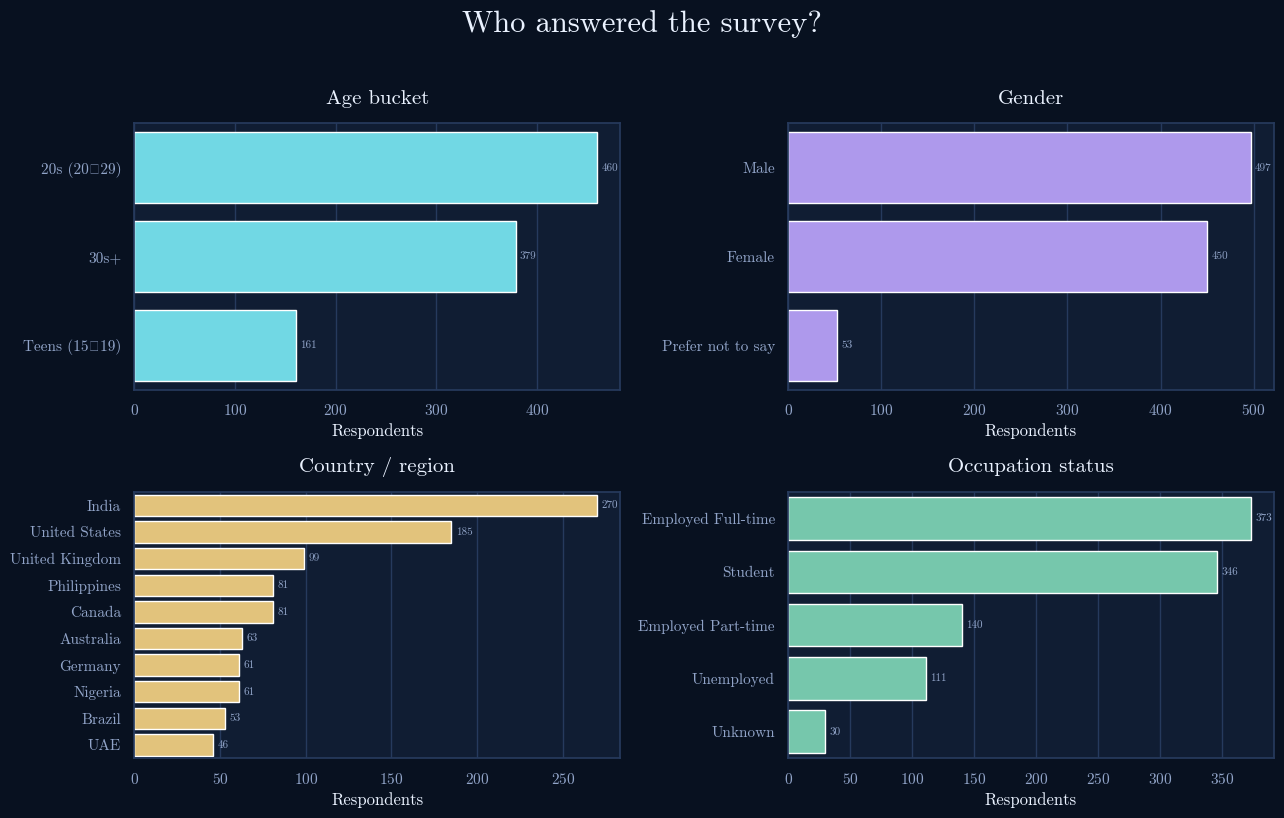

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
panels = [
    ('age_bucket', 'Age bucket', COLORS['cyan']),
    ('gender', 'Gender', COLORS['violet']),
    ('country_region', 'Country / region', COLORS['gold']),
    ('occupation_status', 'Occupation status', COLORS['mint']),
]
for ax, (col, title, color) in zip(axes.flat, panels):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color=color)
    ax.set_title(title); ax.set_xlabel('Respondents'); ax.set_ylabel('')
    for container in ax.containers: ax.bar_label(container, padding=3, color=COLORS['muted'], fontsize=8)
fig.suptitle('Who answered the survey?', fontsize=22, fontweight='bold', y=1.02)
fig.tight_layout()
save_chart(fig, '01_descriptive_overview.png')

**Figure 1 takeaway.** The sample is concentrated in the 20s and 30s+, with India and the United States the largest country groups. Gender is comparatively balanced, while full-time workers and students together make up most respondents; these compositional differences matter when comparing subgroup rates.

## 5. Q1–2: Core relationship

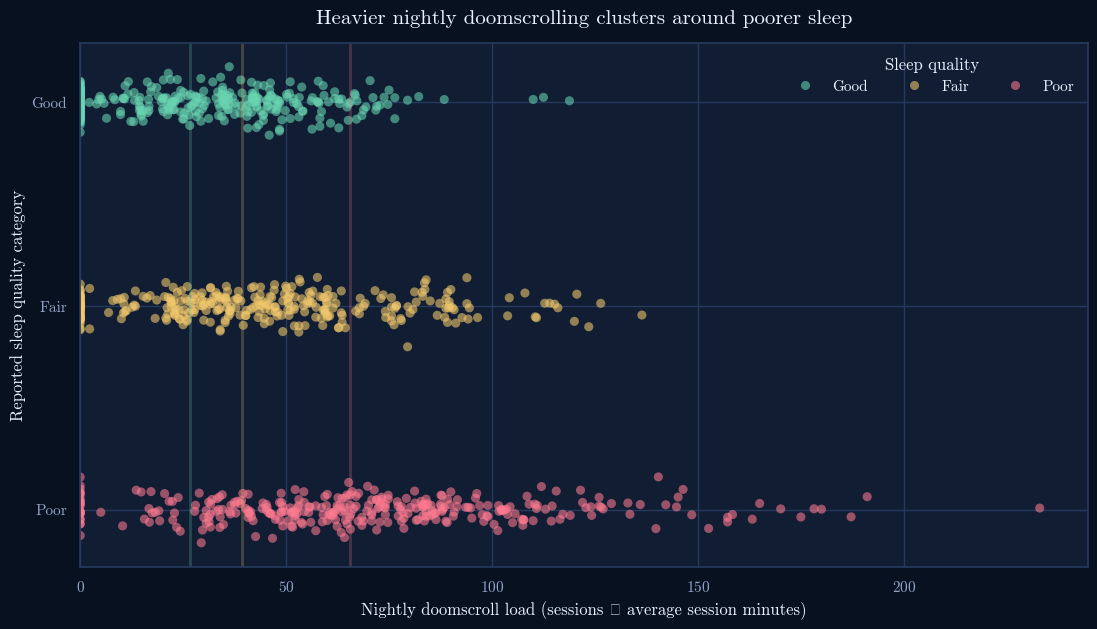

In [5]:
plot_df = df.copy()
cat_order = ['Good', 'Fair', 'Poor']
cat_y = {'Good': 2, 'Fair': 1, 'Poor': 0}
plot_df['sleep_category_numeric'] = plot_df['sleep_quality_category'].map(cat_y).astype(float)
rng = np.random.default_rng(RANDOM_STATE)
plot_df['sleep_category_jitter'] = plot_df['sleep_category_numeric'] + rng.normal(0, .055, len(plot_df))

fig, ax = plt.subplots(figsize=(13, 6.8))
sns.scatterplot(
    data=plot_df, x='doomscroll_load_minutes', y='sleep_category_jitter',
    hue='sleep_quality_category', hue_order=cat_order,
    palette={'Good': COLORS['mint'], 'Fair': COLORS['gold'], 'Poor': COLORS['red']},
    alpha=.58, s=43, linewidth=0, ax=ax
)
q = plot_df.groupby('sleep_quality_category')['doomscroll_load_minutes'].median().reindex(cat_order)
for label, value in q.items():
    ax.axvline(value, color={'Good': COLORS['mint'], 'Fair': COLORS['gold'], 'Poor': COLORS['red']}[label],
               alpha=.24, lw=2)
ax.set_yticks([0,1,2], ['Poor', 'Fair', 'Good'])
ax.set_xlim(left=0); ax.set_xlabel('Nightly doomscroll load (sessions × average session minutes)')
ax.set_ylabel('Reported sleep quality category')
ax.set_title('Heavier nightly doomscrolling clusters around poorer sleep')
ax.legend(title='Sleep quality', frameon=False, ncol=3, loc='upper right')
save_chart(fig, '02_hero_doomscroll_sleep.png')

**Figure 2 takeaway.** Poor sleepers carry the highest median nightly doomscroll load, while good sleepers cluster at lower loads. The overlap is substantial—some heavy scrollers still report good sleep—so doomscrolling is a risk signal rather than a deterministic label.

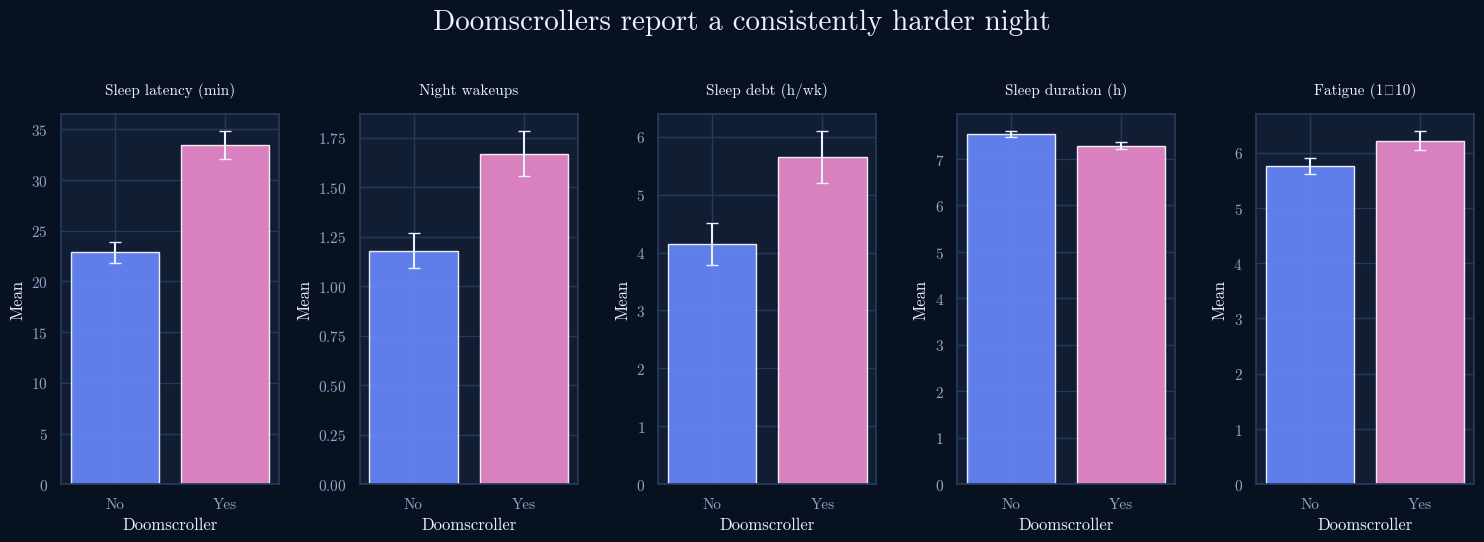

In [6]:
outcomes = {
    'Sleep latency (min)': 'sleep_latency_minutes',
    'Night wakeups': 'number_of_night_wakeups',
    'Sleep debt (h/wk)': 'weekly_sleep_debt_hours',
    'Sleep duration (h)': 'sleep_hours_per_night',
    'Fatigue (1–10)': 'daytime_fatigue_score',
}
rows=[]
for label, col in outcomes.items():
    g=df.groupby('doomscroller')[col].agg(['mean','std','count'])
    for status in ['No','Yes']:
        rows.append({'Outcome':label,'Doomscroller':status,'Mean':g.loc[status,'mean'],
                     'SE':g.loc[status,'std']/np.sqrt(g.loc[status,'count'])})
comp=pd.DataFrame(rows)
fig, axes=plt.subplots(1, len(outcomes), figsize=(15,5.3))
for ax,(label,_) in zip(axes,outcomes.items()):
    d=comp[comp.Outcome.eq(label)]
    ax.bar(['No','Yes'],d.Mean,color=[COLORS['blue'],COLORS['pink']],alpha=.9)
    ax.errorbar([0,1],d.Mean,yerr=1.96*d.SE,fmt='none',ecolor=COLORS['ink'],capsize=4)
    ax.set_title(label,fontsize=11); ax.set_xlabel('Doomscroller'); ax.set_ylabel('Mean')
fig.suptitle('Doomscrollers report a consistently harder night',fontsize=21,fontweight='bold',y=1.02)
fig.tight_layout(); save_chart(fig,'03_doomscroller_comparison.png')

**Figure 3 takeaway.** Respondents labeled doomscrollers average about 10.6 extra minutes of sleep latency, more wakeups, and roughly 1.5 additional hours of weekly sleep debt. They also sleep about 15 minutes less per night and report more daytime fatigue; these gaps are descriptive and may share common causes.

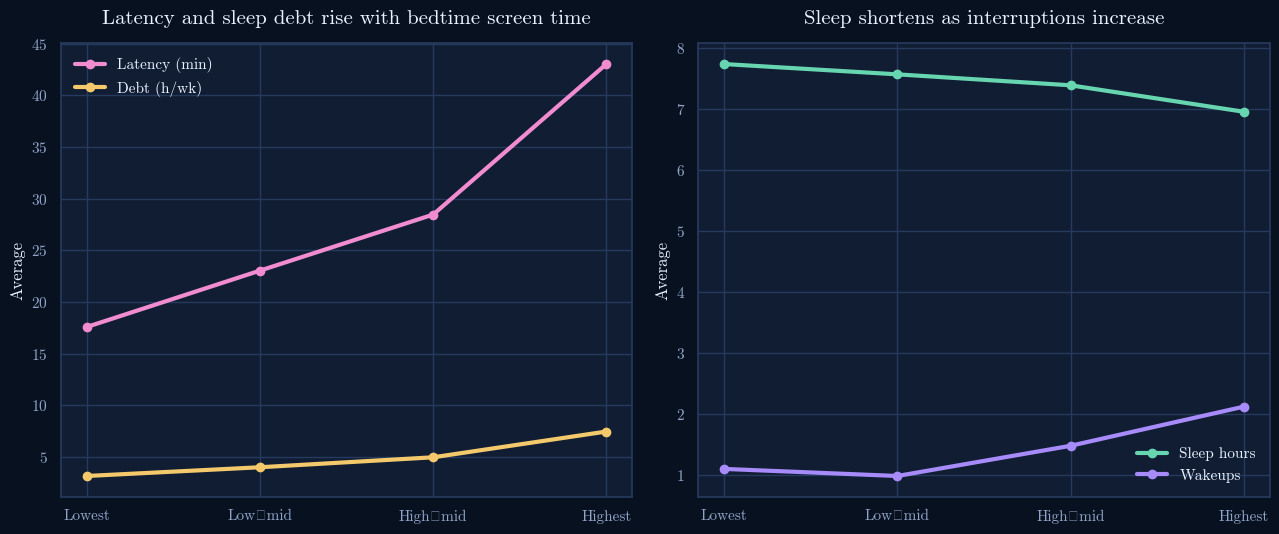

In [7]:
dose = df.groupby('bedtime_screen_quartile', observed=True).agg(
    latency=('sleep_latency_minutes','mean'), debt=('weekly_sleep_debt_hours','mean'),
    wakeups=('number_of_night_wakeups','mean'), sleep=('sleep_hours_per_night','mean')
).reset_index()
fig, axes=plt.subplots(1,2,figsize=(13,5.5))
x=np.arange(len(dose))
axes[0].plot(x,dose.latency,marker='o',lw=3,color=COLORS['pink'],label='Latency (min)')
axes[0].plot(x,dose.debt,marker='o',lw=3,color=COLORS['gold'],label='Debt (h/wk)')
axes[0].set_xticks(x,dose.bedtime_screen_quartile); axes[0].set_title('Latency and sleep debt rise with bedtime screen time')
axes[0].legend(frameon=False); axes[0].set_ylabel('Average')
axes[1].plot(x,dose.sleep,marker='o',lw=3,color=COLORS['mint'],label='Sleep hours')
axes[1].plot(x,dose.wakeups,marker='o',lw=3,color=COLORS['violet'],label='Wakeups')
axes[1].set_xticks(x,dose.bedtime_screen_quartile); axes[1].set_title('Sleep shortens as interruptions increase')
axes[1].legend(frameon=False); axes[1].set_ylabel('Average')
fig.tight_layout(); save_chart(fig,'04_dose_response.png')

**Figure 4 takeaway.** The relationship is dose-shaped rather than confined to a yes/no label: each higher bedtime-screen quartile brings longer latency and more sleep debt. The highest quartile also averages fewer sleep hours and more wakeups, making bedtime exposure the clearest continuous behavioral signal in the file.

## 6. Q3–4: Mental health angle

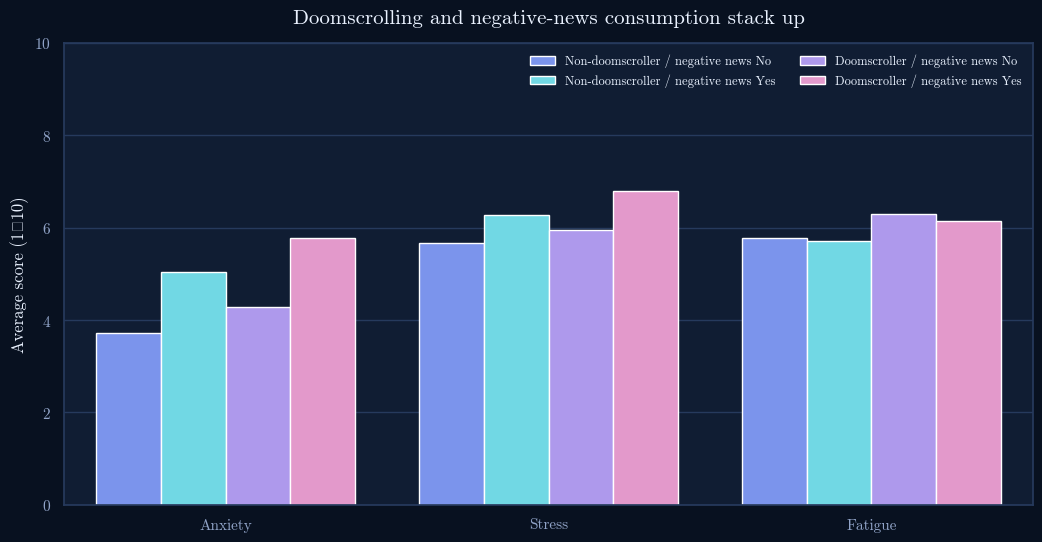

In [8]:
mental=['anxiety_score','stress_score','daytime_fatigue_score']
mh=df.groupby(['doomscroller','consumes_negative_news_content'])[mental].mean().reset_index()
mh_long=mh.melt(['doomscroller','consumes_negative_news_content'],var_name='Measure',value_name='Mean')
mh_long['Group']=mh_long['doomscroller'].map({'No':'Non-doomscroller','Yes':'Doomscroller'})+' / negative news '+mh_long['consumes_negative_news_content']
mh_long['Measure']=mh_long.Measure.map({'anxiety_score':'Anxiety','stress_score':'Stress','daytime_fatigue_score':'Fatigue'})
fig,ax=plt.subplots(figsize=(12.5,6))
sns.barplot(data=mh_long,x='Measure',y='Mean',hue='Group',palette=[COLORS['blue'],COLORS['cyan'],COLORS['violet'],COLORS['pink']],ax=ax)
ax.set_ylim(0,10); ax.set_ylabel('Average score (1–10)'); ax.set_xlabel('')
ax.set_title('Doomscrolling and negative-news consumption stack up')
ax.legend(frameon=False,ncol=2,fontsize=9,title='')
save_chart(fig,'05_mental_health.png')

**Figure 5 takeaway.** Doomscrollers report higher anxiety, stress, and fatigue than non-doomscrollers, and negative-news consumption generally adds to that burden. The highest averages occur when both behaviors are present, but cross-sectional self-report data cannot distinguish direction: distress may also drive more scrolling.

## 7. Q5–6: Protective habits

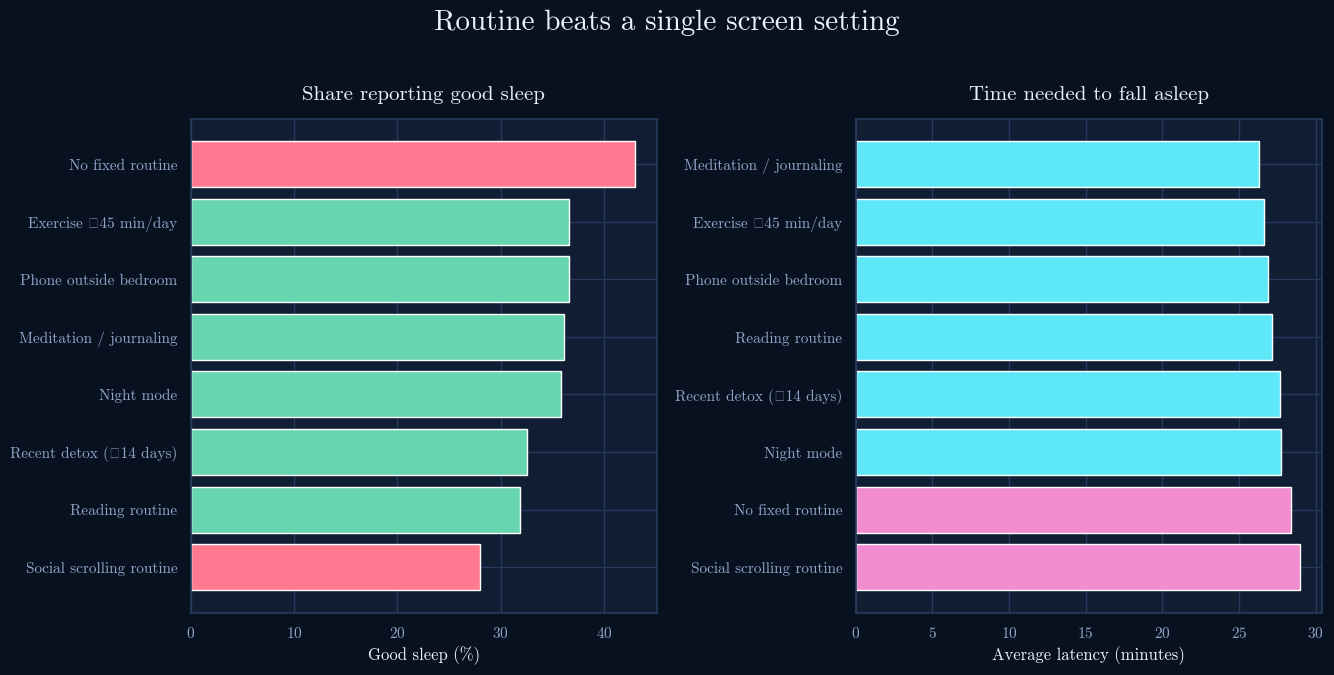

In [9]:
habits = []
def add_habit(label, mask):
    d=df[mask]
    habits.append({'Habit':label,'N':len(d),'Good sleep %':100*d.sleep_quality_category.eq('Good').mean(),
                   'Latency':d.sleep_latency_minutes.mean(),'Debt':d.weekly_sleep_debt_hours.mean()})
add_habit('Phone outside bedroom',df.keeps_phone_in_bedroom.eq('No'))
add_habit('Night mode',df.uses_night_mode.eq('Yes'))
add_habit('Reading routine',df.bedtime_routine_type.eq('Reading'))
add_habit('Meditation / journaling',df.bedtime_routine_type.eq('Meditation/Journaling'))
add_habit('Recent detox (≤14 days)',df.days_since_last_digital_detox.le(14))
add_habit('Exercise ≥45 min/day',df.exercise_minutes_per_day.ge(45))
add_habit('No fixed routine',df.bedtime_routine_type.eq('No Fixed Routine'))
add_habit('Social scrolling routine',df.bedtime_routine_type.eq('Scrolling Social Media'))
habits=pd.DataFrame(habits)
fig,axes=plt.subplots(1,2,figsize=(13.5,6.6))
order=habits.sort_values('Good sleep %',ascending=True)
axes[0].barh(order.Habit,order['Good sleep %'],color=[COLORS['red'] if 'Social' in x or 'No fixed' in x else COLORS['mint'] for x in order.Habit])
axes[0].set_xlabel('Good sleep (%)'); axes[0].set_title('Share reporting good sleep')
order2=habits.sort_values('Latency',ascending=False)
axes[1].barh(order2.Habit,order2.Latency,color=[COLORS['pink'] if 'Social' in x or 'No fixed' in x else COLORS['cyan'] for x in order2.Habit])
axes[1].set_xlabel('Average latency (minutes)'); axes[1].set_title('Time needed to fall asleep')
fig.suptitle('Routine beats a single screen setting',fontsize=21,fontweight='bold',y=1.02)
fig.tight_layout(); save_chart(fig,'06_protective_habits.png')

**Figure 6 takeaway.** Reading and meditation/journaling routines stand out more consistently than night mode alone, while a social-scrolling bedtime routine has the weakest profile. Keeping the phone outside the bedroom and regular exercise also align with better outcomes, suggesting that environment and routine may matter more than display settings.

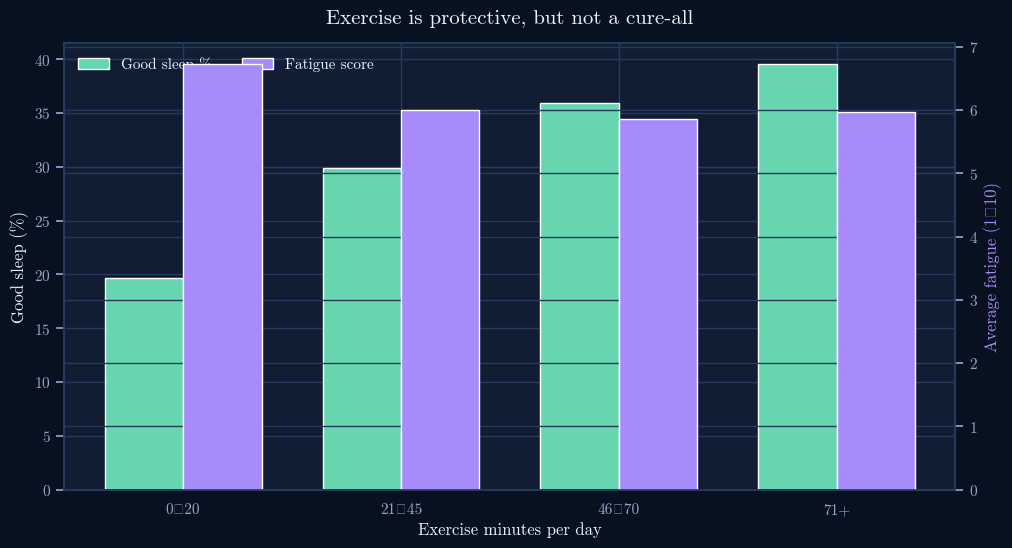

In [10]:
ex_bins=pd.cut(df.exercise_minutes_per_day,[-.1,20,45,70,np.inf],labels=['0–20','21–45','46–70','71+'])
ex=df.assign(exercise_band=ex_bins).groupby('exercise_band',observed=True).agg(
    good_sleep=('sleep_quality_category',lambda s:100*s.eq('Good').mean()),
    fatigue=('daytime_fatigue_score','mean'), sleep=('sleep_hours_per_night','mean')
).reset_index()
fig,ax=plt.subplots(figsize=(11.5,5.8))
ax2=ax.twinx(); x=np.arange(len(ex))
ax.bar(x-.18,ex.good_sleep,.36,color=COLORS['mint'],label='Good sleep %')
ax2.bar(x+.18,ex.fatigue,.36,color=COLORS['violet'],label='Fatigue score')
ax.set_xticks(x,ex.exercise_band); ax.set_xlabel('Exercise minutes per day')
ax.set_ylabel('Good sleep (%)'); ax2.set_ylabel('Average fatigue (1–10)',color=COLORS['violet'])
ax.set_title('Exercise is protective, but not a cure-all')
lines,labels=ax.get_legend_handles_labels(); lines2,labels2=ax2.get_legend_handles_labels()
ax.legend(lines+lines2,labels+labels2,frameon=False,ncol=2,loc='upper left')
save_chart(fig,'07_exercise_gradient.png')

**Figure 7 takeaway.** More active respondents are somewhat more likely to report good sleep and tend to report less fatigue. The gradient is modest and non-monotonic in places, reinforcing that exercise appears helpful but does not erase the effect of a highly disruptive nighttime routine.

## 8. Q7–8: Demographic breakdowns

Gender is presented descriptively only. Subgroup differences may reflect sample composition and are not interpreted as inherent traits.

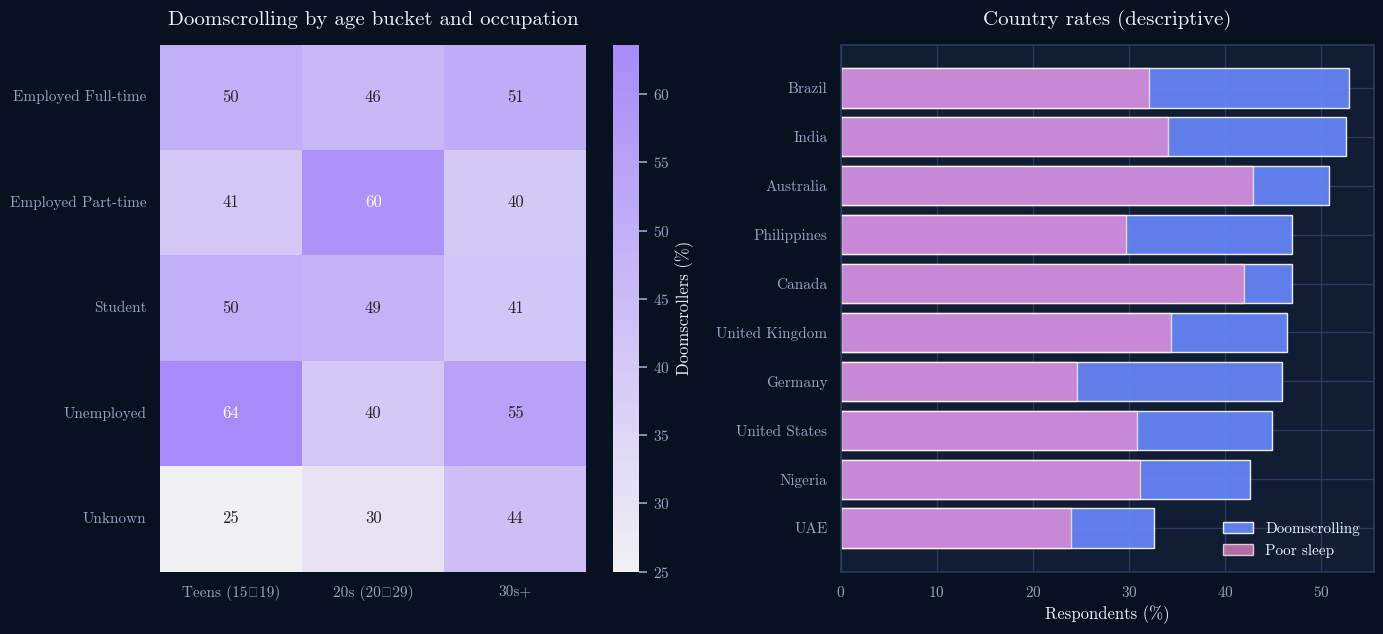

In [11]:
age_order=['Teens (15–19)','20s (20–29)','30s+']
demo=df.groupby(['age_bucket','occupation_status'],observed=True).agg(
    doom_rate=('doomscroller',lambda s:100*s.eq('Yes').mean()),
    poor_sleep=('sleep_quality_category',lambda s:100*s.eq('Poor').mean()),
    n=('respondent_id','size')
).reset_index()
p1=demo.pivot(index='occupation_status',columns='age_bucket',values='doom_rate').reindex(columns=age_order)
country=df.groupby('country_region').agg(doom_rate=('doomscroller',lambda s:100*s.eq('Yes').mean()),poor_sleep=('sleep_quality_category',lambda s:100*s.eq('Poor').mean()),n=('respondent_id','size')).sort_values('doom_rate')
fig,axes=plt.subplots(1,2,figsize=(14,6.5))
sns.heatmap(p1,annot=True,fmt='.0f',cmap=sns.light_palette(COLORS['violet'],as_cmap=True),cbar_kws={'label':'Doomscrollers (%)'},ax=axes[0])
axes[0].set_title('Doomscrolling by age bucket and occupation'); axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[1].barh(country.index,country.doom_rate,color=COLORS['blue'],alpha=.9,label='Doomscrolling')
axes[1].barh(country.index,country.poor_sleep,color=COLORS['pink'],alpha=.72,label='Poor sleep')
axes[1].set_xlabel('Respondents (%)'); axes[1].set_title('Country rates (descriptive)'); axes[1].legend(frameon=False)
fig.tight_layout(); save_chart(fig,'08_demographics.png')

**Figure 8 takeaway.** Doomscrolling varies across age–occupation cells, with student and younger-adult pockets often elevated, but some cells are small and unstable. Country patterns also differ, yet they should be treated as descriptive sample signals rather than cultural rankings because country sample sizes range widely.

**Gender note.** Figure 1 shows the gender composition; outcome checks found only modest differences in doomscrolling, poor-sleep share, and latency. Gender remains descriptive only, and the smallest group is much less precisely estimated.

## 9. The Exceptions

Heavy doomscrollers are defined as self-identified doomscrollers in the top quartile of bedtime screen time. “Exceptions” are members of that group who still report good sleep.

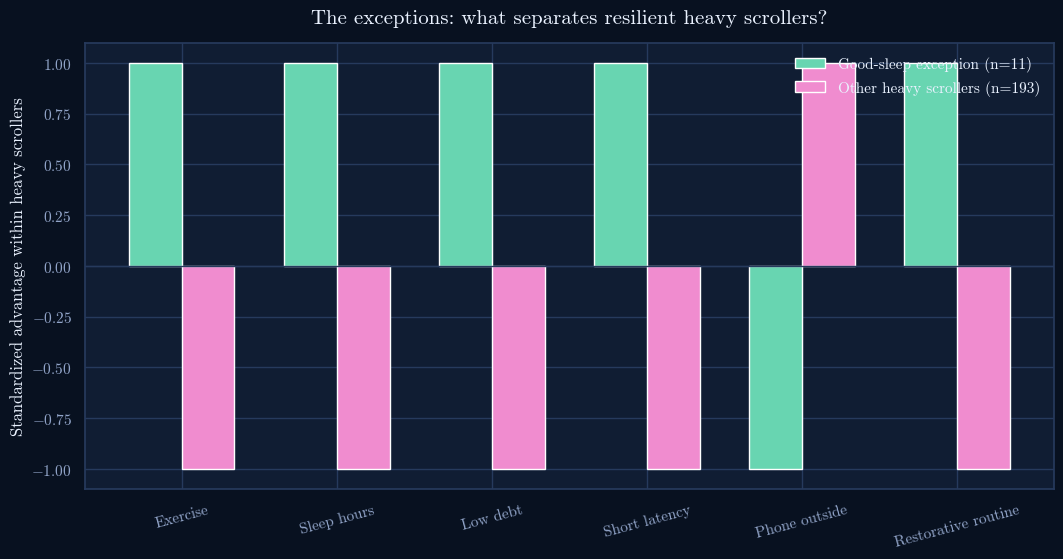

In [12]:
heavy_cut=df.bedtime_screen_time_minutes.quantile(.75)
heavy=df[df.doomscroller.eq('Yes') & df.bedtime_screen_time_minutes.ge(heavy_cut)].copy()
heavy['Exception']=np.where(heavy.sleep_quality_category.eq('Good'),'Good-sleep exception','Other heavy scrollers')
exc=heavy.groupby('Exception').agg(
    n=('respondent_id','size'), exercise=('exercise_minutes_per_day','mean'),
    sleep_hours=('sleep_hours_per_night','mean'), debt=('weekly_sleep_debt_hours','mean'),
    latency=('sleep_latency_minutes','mean'), phone_out=('keeps_phone_in_bedroom',lambda s:100*s.eq('No').mean()),
    restorative_routine=('bedtime_routine_type',lambda s:100*s.isin(['Reading','Meditation/Journaling']).mean())
)
metrics=['exercise','sleep_hours','debt','latency','phone_out','restorative_routine']
z=(exc[metrics]-exc[metrics].mean())/exc[metrics].std(ddof=0)
z[['debt','latency']]*=-1
fig,ax=plt.subplots(figsize=(12.5,5.8))
x=np.arange(len(metrics)); w=.34
labels=['Exercise','Sleep hours','Low debt','Short latency','Phone outside','Restorative routine']
for i,(idx,row) in enumerate(z.iterrows()):
    ax.bar(x+(i-.5)*w,row.values,w,label=f"{idx} (n={int(exc.loc[idx,'n'])})",color=[COLORS['mint'],COLORS['pink']][i])
ax.axhline(0,color=COLORS['grid'],lw=1); ax.set_xticks(x,labels,rotation=15)
ax.set_ylabel('Standardized advantage within heavy scrollers'); ax.set_title('The exceptions: what separates resilient heavy scrollers?')
ax.legend(frameon=False); save_chart(fig,'10_exceptions.png')

**Figure 9 takeaway.** Only a small minority of heavy doomscrollers still report good sleep, making this a counter-narrative rather than the norm. They distinguish themselves mainly through longer actual sleep, lower debt/latency, and a higher prevalence of reading or meditation routines; the tiny exception group means these clues are exploratory.

## 10. Personas

Personas are transparent rules, not diagnoses or hidden clusters. They summarize combinations a product team can design for while keeping every respondent’s underlying measures intact.

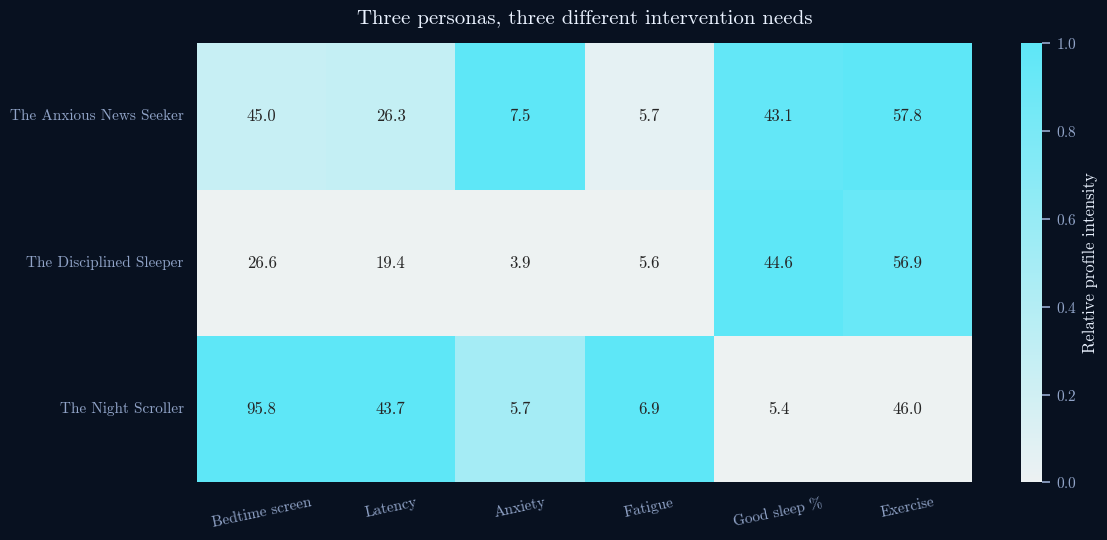

,n,screen,latency,anxiety,fatigue,good,exercise
persona,,,,,,,
The Anxious News Seeker,51,44.960784,26.313725,7.549020,5.705882,43.137255,57.843137
The Disciplined Sleeper,130,26.576923,19.361538,3.900000,5.638462,44.615385,56.938462
The Night Scroller,204,95.823529,43.696078,5.730392,6.916667,5.392157,45.980392


In [13]:
q75=df.bedtime_screen_time_minutes.quantile(.75); med=df.bedtime_screen_time_minutes.median()
conditions=[
    df.doomscroller.eq('Yes') & df.bedtime_screen_time_minutes.ge(q75),
    df.consumes_negative_news_content.eq('Yes') & df.anxiety_score.ge(7) & df.stress_score.ge(7),
    df.bedtime_screen_time_minutes.le(med) & df.bedtime_routine_type.isin(['Reading','Meditation/Journaling'])
]
choices=['The Night Scroller','The Anxious News Seeker','The Disciplined Sleeper']
df['persona']=np.select(conditions,choices,default='The Balanced Middle')
p=df[df.persona.ne('The Balanced Middle')].groupby('persona').agg(
    n=('respondent_id','size'), screen=('bedtime_screen_time_minutes','mean'),
    latency=('sleep_latency_minutes','mean'), anxiety=('anxiety_score','mean'),
    fatigue=('daytime_fatigue_score','mean'), good=('sleep_quality_category',lambda s:100*s.eq('Good').mean()),
    exercise=('exercise_minutes_per_day','mean')
)
radar=p[['screen','latency','anxiety','fatigue','good','exercise']]
radar=(radar-radar.min())/(radar.max()-radar.min()).replace(0,1)
fig,ax=plt.subplots(figsize=(12.5,5.7))
sns.heatmap(radar,annot=p[['screen','latency','anxiety','fatigue','good','exercise']].round(1),fmt='',cmap=sns.light_palette(COLORS['cyan'],as_cmap=True),cbar_kws={'label':'Relative profile intensity'},ax=ax)
ax.set_xticklabels(['Bedtime screen','Latency','Anxiety','Fatigue','Good sleep %','Exercise'],rotation=12)
ax.set_xlabel(''); ax.set_ylabel(''); ax.set_title('Three personas, three different intervention needs')
save_chart(fig,'11_personas.png')
display(p)

**Figure 10 takeaway.** The Night Scroller is defined by exposure and delayed sleep, the Anxious News Seeker by emotional load, and the Disciplined Sleeper by lower exposure plus a restorative routine. The profiles argue against a one-size-fits-all intervention: environment, content, and routine are different levers for different respondents.

## 11. Q9: Synthesis — correlation heatmap and feature importance

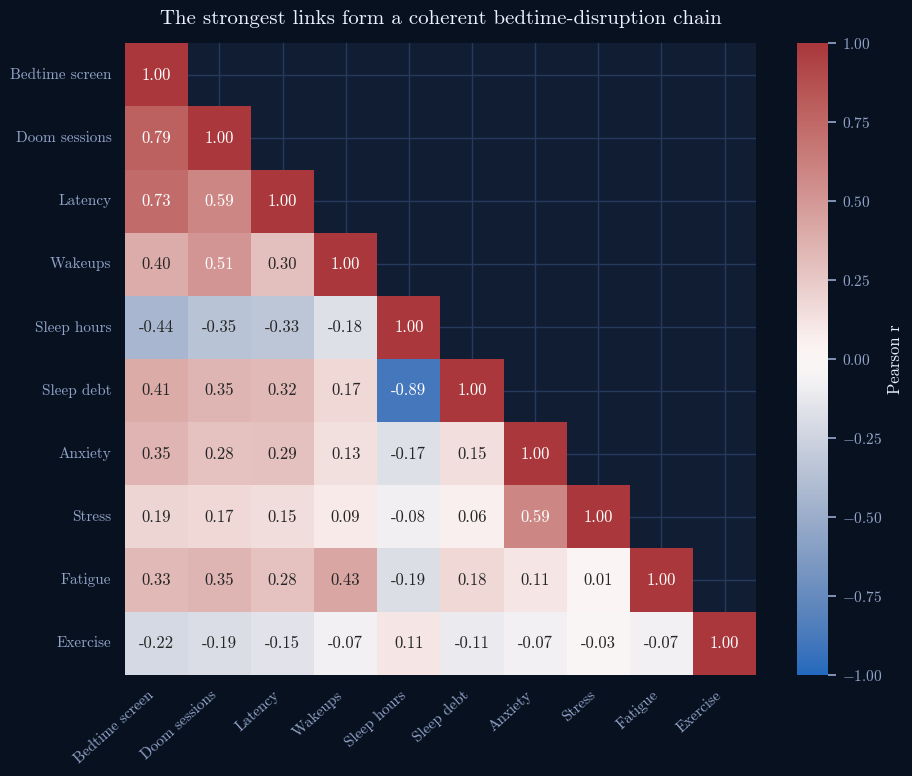

In [14]:
synth_cols=['bedtime_screen_time_minutes','doomscroll_sessions_per_night','sleep_latency_minutes','number_of_night_wakeups','sleep_hours_per_night','weekly_sleep_debt_hours','anxiety_score','stress_score','daytime_fatigue_score','exercise_minutes_per_day']
labels=['Bedtime screen','Doom sessions','Latency','Wakeups','Sleep hours','Sleep debt','Anxiety','Stress','Fatigue','Exercise']
cm=df[synth_cols].corr()
fig,ax=plt.subplots(figsize=(10.5,8.2))
sns.heatmap(cm,mask=np.triu(np.ones_like(cm,dtype=bool),k=1),cmap='vlag',center=0,vmin=-1,vmax=1,annot=True,fmt='.2f',square=True,cbar_kws={'label':'Pearson r'},ax=ax)
ax.set_xticklabels(labels,rotation=42,ha='right'); ax.set_yticklabels(labels,rotation=0)
ax.set_title('The strongest links form a coherent bedtime-disruption chain')
save_chart(fig,'12_correlation_heatmap.png')

**Figure 11 takeaway.** Bedtime screen time links strongly to doomscroll sessions and latency, while wakeups track nighttime phone checks and sleep debt opposes sleep duration. The clean chain is substantively coherent but also reinforces the synthetic-data warning: several variables appear jointly engineered around a common disruption pattern.

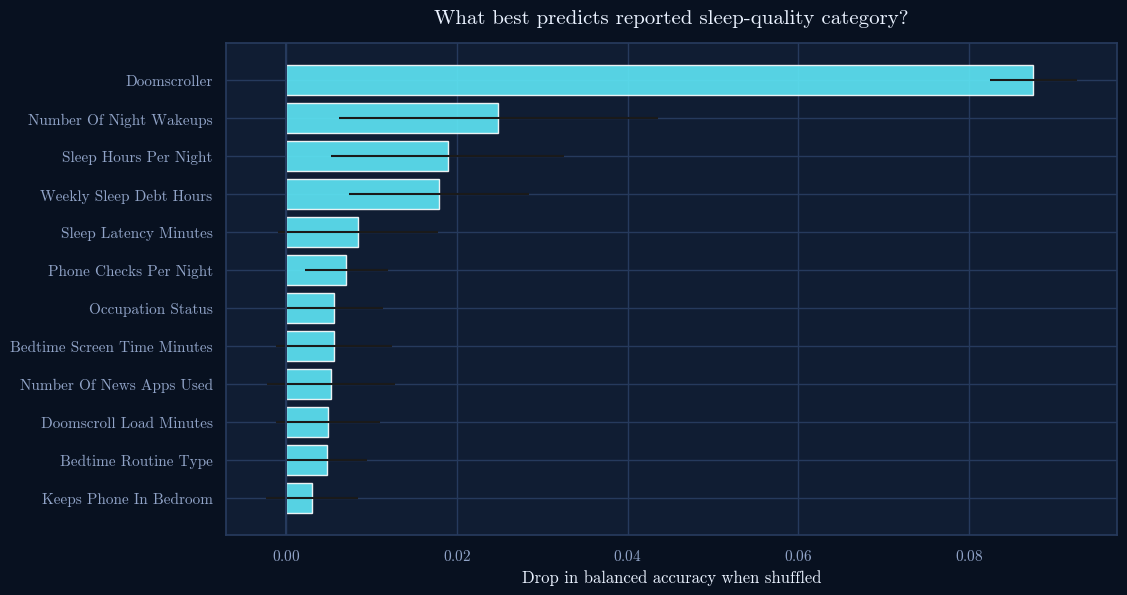

Holdout accuracy: 0.576
Holdout balanced accuracy: 0.575
5-fold balanced accuracy: 0.603 ± 0.026
Majority-class baseline: 0.340


,feature,importance,sd
25,doomscroller,0.087548,0.005057
6,number_of_night_wakeups,0.024859,0.018657
4,sleep_hours_per_night,0.018902,0.013599
15,weekly_sleep_debt_hours,0.017885,0.010554
5,sleep_latency_minutes,0.008382,0.009382
12,phone_checks_per_night,0.007041,0.004893
17,occupation_status,0.005615,0.005769
0,bedtime_screen_time_minutes,0.005596,0.006845
11,number_of_news_apps_used,0.005244,0.007532
27,doomscroll_load_minutes,0.004906,0.006090


In [15]:
target='sleep_quality_category'
excluded={'respondent_id',target,'sleep_quality_score','age','bedtime_screen_quartile','persona'}
feature_cols=[c for c in df.columns if c not in excluded]
X=df[feature_cols].copy(); y=df[target]
cat=[c for c in X.columns if str(X[c].dtype) in ('object','string','category')]
num=[c for c in X.columns if c not in cat]
preprocess=ColumnTransformer([
    ('num',Pipeline([('imputer',SimpleImputer(strategy='median'))]),num),
    ('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat)
])
model=RandomForestClassifier(n_estimators=500,min_samples_leaf=4,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1)
pipe=Pipeline([('prep',preprocess),('model',model)])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,stratify=y,random_state=RANDOM_STATE)
pipe.fit(X_train,y_train)
pred=pipe.predict(X_test)
cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
cv_scores=cross_val_score(pipe,X,y,cv=cv,scoring='balanced_accuracy',n_jobs=-1)
fold_importances=[]
for train_idx,test_idx in cv.split(X,y):
    fold_model=clone(pipe).fit(X.iloc[train_idx],y.iloc[train_idx])
    fold_perm=permutation_importance(
        fold_model,X.iloc[test_idx],y.iloc[test_idx],n_repeats=8,
        random_state=RANDOM_STATE,scoring='balanced_accuracy',n_jobs=-1
    )
    fold_importances.append(fold_perm.importances_mean)
importance=pd.DataFrame({
    'feature':feature_cols,
    'importance':np.mean(fold_importances,axis=0),
    'sd':np.std(fold_importances,axis=0)
}).sort_values('importance',ascending=False)
top=importance.head(12).sort_values('importance')
fig,ax=plt.subplots(figsize=(11.5,6.4))
ax.barh(top.feature.str.replace('_',' ').str.title(),top.importance,xerr=top.sd,color=[COLORS['cyan'] if x>0 else COLORS['muted'] for x in top.importance],alpha=.9)
ax.axvline(0,color=COLORS['grid']); ax.set_xlabel('Drop in balanced accuracy when shuffled')
ax.set_title('What best predicts reported sleep-quality category?')
save_chart(fig,'13_feature_importance.png')
print(f"Holdout accuracy: {accuracy_score(y_test,pred):.3f}")
print(f"Holdout balanced accuracy: {balanced_accuracy_score(y_test,pred):.3f}")
print(f"5-fold balanced accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Majority-class baseline: {y.value_counts(normalize=True).max():.3f}")
display(importance.head(15))

**Figure 12 takeaway.** The doomscroller label is the strongest cross-validated predictor, followed by wakeups, sleep duration, sleep debt, and latency; correlated exposure measures share signal and therefore look weaker when shuffled one at a time. The model is predictive, not causal, and outcome-adjacent `sleep_quality_score` was intentionally excluded to avoid an obvious construct-overlap shortcut.

## 12. Summary of findings

1. **Bedtime exposure is the central signal.** Doomscrollers average longer latency, more wakeups, more debt, and slightly shorter sleep; the continuous screen-time gradient is clearer than the binary label alone.
2. **Mental load compounds the pattern.** Anxiety, stress, and fatigue are highest where doomscrolling and negative-news consumption coexist.
3. **Routines appear more protective than settings.** Reading, meditation/journaling, keeping the phone outside the bedroom, and exercise align with better sleep; night mode alone is comparatively weak.
4. **Demographics add context, not destiny.** Age–occupation and country rates vary, but behavior is more actionable and generally more predictive. Gender remains descriptive only.
5. **Exceptions matter.** A small set of heavy scrollers still sleep well, often alongside restorative routines and lower realized sleep debt—evidence that exposure does not determine outcome by itself.
6. **Synthetic structure limits inference.** Strong engineered correlations, balanced target classes, and the sleep-score ceiling mean effect sizes should not be generalized beyond this dataset.

### Practical interpretation
The most plausible intervention sequence is: reduce bedtime screen exposure, move the phone away from the sleep environment, replace social/news scrolling with a fixed restorative routine, and protect daytime movement. These are evidence-informed hypotheses for testing—not medical advice.

In [16]:
def mean_by(group, col, value):
    return float(df.loc[df[group].eq(value), col].mean())
doom_means=df.groupby('doomscroller').mean(numeric_only=True)
summary={
    'n':len(df), 'columns_total':df_raw.shape[1], 'analytic_variables':df_raw.shape[1]-1,
    'missing_cells_before':int(df_raw.isna().sum().sum()),
    'doomscroller_rate':float(df.doomscroller.eq('Yes').mean()),
    'poor_sleep_rate':float(df.sleep_quality_category.eq('Poor').mean()),
    'latency_gap_minutes':float(doom_means.loc['Yes','sleep_latency_minutes']-doom_means.loc['No','sleep_latency_minutes']),
    'sleep_debt_gap_hours':float(doom_means.loc['Yes','weekly_sleep_debt_hours']-doom_means.loc['No','weekly_sleep_debt_hours']),
    'sleep_duration_gap_hours':float(doom_means.loc['Yes','sleep_hours_per_night']-doom_means.loc['No','sleep_hours_per_night']),
    'screen_latency_r':float(df.bedtime_screen_time_minutes.corr(df.sleep_latency_minutes)),
    'sleep_debt_hours_r':float(df.sleep_hours_per_night.corr(df.weekly_sleep_debt_hours)),
    'heavy_threshold':float(heavy_cut), 'heavy_n':int(len(heavy)),
    'exception_n':int(heavy.sleep_quality_category.eq('Good').sum()),
    'cv_balanced_accuracy':float(cv_scores.mean()), 'baseline_accuracy':float(y.value_counts(normalize=True).max()),
    'top_predictors':importance.head(8).feature.tolist(),
    'persona_counts':df.persona.value_counts().to_dict(),
    'missing_by_column':missing_before.astype(int).to_dict(),
}
(ROOT/'analysis_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
importance.to_csv(ROOT/'feature_importance.csv',index=False)
habits.to_csv(ROOT/'protective_habits_summary.csv',index=False)
p.reset_index().to_csv(ROOT/'persona_summary.csv',index=False)
print(json.dumps(summary,indent=2))

{
  "n": 1000,
  "columns_total": 30,
  "analytic_variables": 29,
  "missing_cells_before": 220,
  "doomscroller_rate": 0.476,
  "poor_sleep_rate": 0.33,
  "latency_gap_minutes": 10.561004554493554,
  "sleep_debt_gap_hours": 1.4901869908268655,
  "sleep_duration_gap_hours": -0.24751106549490043,
  "screen_latency_r": 0.729464420495972,
  "sleep_debt_hours_r": -0.8932909708524149,
  "heavy_threshold": 66.0,
  "heavy_n": 204,
  "exception_n": 11,
  "cv_balanced_accuracy": 0.6028520499108734,
  "baseline_accuracy": 0.34,
  "top_predictors": [
    "doomscroller",
    "number_of_night_wakeups",
    "sleep_hours_per_night",
    "weekly_sleep_debt_hours",
    "sleep_latency_minutes",
    "phone_checks_per_night",
    "occupation_status",
    "bedtime_screen_time_minutes"
  ],
  "persona_counts": {
    "The Balanced Middle": 615,
    "The Night Scroller": 204,
    "The Disciplined Sleeper": 130,
    "The Anxious News Seeker": 51
  },
  "missing_by_column": {
    "caffeine_intake_mg_per_day": 5